In [3]:
import jax
import jax.numpy as jnp
from jax.experimental.ode import odeint# Verify we're using CPU
print(f"JAX backend: {jax.default_backend()}")
print(f"Available devices: {jax.devices()}")



JAX backend: cpu
Available devices: [CpuDevice(id=0)]


In [4]:

# 1) Problem setup
N = 5
mass = 1.0

def unpack_params(p):
    k = p[0]
    beta = p[1:]
    return k, beta

def forcing(t):
    return jnp.array([jnp.sin(2.0 * t)] + [0.0]*(N-1))

def dynamics(x, t, p):
    # first‐order Duffing chain
    k, beta = unpack_params(p)
    x_pad = jnp.concatenate([jnp.array([0.0]), x, jnp.array([0.0])])
    lap   = x_pad[:-2] + x_pad[2:] - 2*x
    return k*lap - beta*x**3 + forcing(t)

# time grid and true trajectory
p_true   = jnp.array([3.0] + [0.5]*N)
t_final  = 10.0
num_steps= 200
ts       = jnp.linspace(0.0, t_final, num_steps)
init_x   = jnp.zeros(N)

target_states = odeint(dynamics, init_x, ts, p_true)
target_traj   = target_states[:, -1]


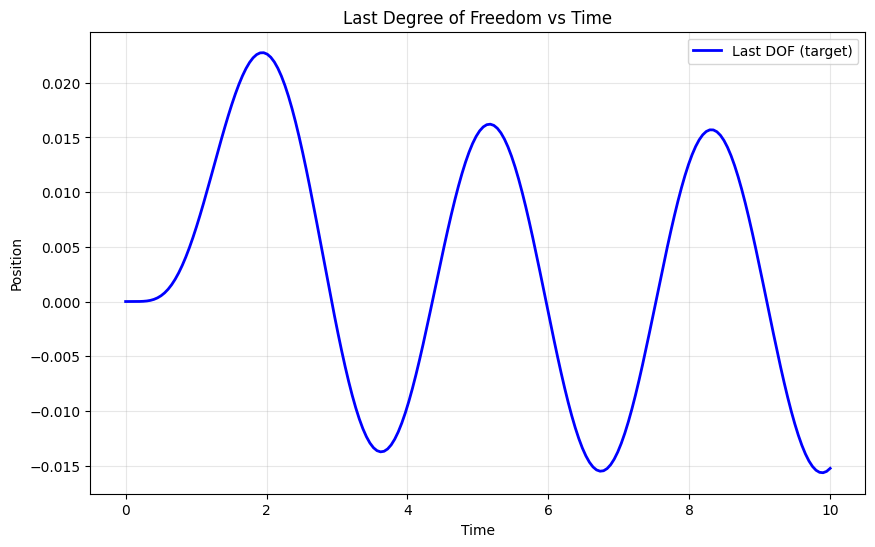

Target trajectory shape: (200,)
Time range: 0.00 to 10.00
Target trajectory range: -0.0157 to 0.0227


In [5]:
import matplotlib.pyplot as plt

# Plot the last DOF (oscillator) over time
plt.figure(figsize=(10, 6))
plt.plot(ts, target_traj, 'b-', linewidth=2, label='Last DOF (target)')
plt.xlabel('Time')
plt.ylabel('Position')
plt.title('Last Degree of Freedom vs Time')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f"Target trajectory shape: {target_traj.shape}")
print(f"Time range: {ts[0]:.2f} to {ts[-1]:.2f}")
print(f"Target trajectory range: {target_traj.min():.4f} to {target_traj.max():.4f}")


In [7]:
# 2) Loss and autodiff gradient
def loss_fn(p):
    xs = odeint(dynamics, init_x, ts, p)
    err= xs[:,-1] - target_traj
    return 0.5*jnp.trapezoid(err**2, ts)

p_test = p_true * 1.1
grad_auto = jax.grad(loss_fn)(p_test)
print("Autodiff gradient:", grad_auto)


Autodiff gradient: [7.7473713e-05 2.5489311e-07 1.9763391e-07 8.6445823e-08 2.7601093e-08
 3.2625709e-09]


In [13]:

# CORRECTED adjoint gradient using working approach
# (a) replay forward trajectory at p_test  
xs = odeint(dynamics, init_x, ts, p_test)

# (b) interpolation helper for target_traj
def target_interp(t):
    return jnp.interp(t, ts, target_traj)

# (c) interpolation helper for state trajectory  
def state_interp(t, x_traj):
    # Interpolate each component of the state vector
    state_components = []
    for i in range(x_traj.shape[1]):
        component = jnp.interp(t, ts, x_traj[:, i])
        state_components.append(component)
    return jnp.array(state_components)

# (d) running‐cost gradient: ∇_x g = (x_end - target) on last DOF
def running_cost_grad_corrected(x, t):
    return jnp.zeros_like(x).at[-1].set(x[-1] - target_interp(t))

# (e) Jacobian of dynamics wrt state
jac_dyn = jax.jacfwd(dynamics, argnums=0)

# (f) adjoint ODE: da/dt = -J^T a - ∇g
def adjoint_ode_corrected(a, t, p, x_traj):
    x = state_interp(t, x_traj)
    J = jac_dyn(x, t, p)
    return -(J.T @ a) - running_cost_grad_corrected(x, t)

# integrate adjoint backward in time
# For backward integration, we need to reverse time: τ = T - t
T = t_final
def adjoint_ode_reversed(a, tau, p, x_traj):
    t = T - tau  # convert back to forward time
    return -adjoint_ode_corrected(a, t, p, x_traj)  # negative because we're going backward

tau_span = jnp.linspace(0.0, T, num_steps)  # τ goes from 0 to T
aT = jnp.zeros(N)  # terminal condition a(T) = 0

# Integrate backward
a_rev = odeint(lambda a, tau: adjoint_ode_reversed(a, tau, p_test, xs), 
               aT, tau_span)

# Convert back to forward time order
a_traj_corrected = a_rev[::-1]

print("CORRECTED Adjoint trajectory shape:", a_traj_corrected.shape)
print("Forward states shape:", xs.shape)

# assemble adjoint gradient
jac_params = jax.jacfwd(dynamics, argnums=2)
ints = []
for a, x, t in zip(a_traj_corrected, xs, ts):
    Jp = jac_params(x, t, p_test)
    ints.append((a[:,None].T @ Jp)[0])
ints = jnp.stack(ints)
grad_adjoint_corrected = -jnp.trapezoid(ints, ts, axis=0)
print("CORRECTED Adjoint gradient:", grad_adjoint_corrected)

# Compare with autodiff
print("Autodiff gradient:      ", grad_auto)
print("Relative error:         ", jnp.abs(grad_adjoint_corrected - grad_auto) / jnp.abs(grad_auto))

CORRECTED Adjoint trajectory shape: (200, 5)
Forward states shape: (200, 5)
CORRECTED Adjoint gradient: [-7.7409350e-05 -2.5475020e-07 -1.9751637e-07 -8.6396803e-08
 -2.7585804e-08 -3.2607257e-09]
Autodiff gradient:       [7.7473713e-05 2.5489311e-07 1.9763391e-07 8.6445823e-08 2.7601093e-08
 3.2625709e-09]
Relative error:          [1.9991692 1.9994394 1.9994051 1.9994328 1.999446  1.9994345]


In [29]:
# CORRECTED adjoint gradient using working approach
# (a) replay forward trajectory at p_test  
xs = odeint(dynamics, init_x, ts, p_test)

# (b) interpolation helper for target_traj
def target_interp(t):
    return jnp.interp(t, ts, target_traj)

# (c) interpolation helper for state trajectory  
def state_interp(t, x_traj):
    # Interpolate each component of the state vector
    state_components = []
    for i in range(x_traj.shape[1]):
        component = jnp.interp(t, ts, x_traj[:, i])
        state_components.append(component)
    return jnp.array(state_components)

# (d) running‐cost gradient: ∇_x g = (x_end - target) on last DOF
def running_cost_grad_corrected(x, t):
    return jnp.zeros_like(x).at[-1].set(x[-1] - target_interp(t))

# (e) Jacobian of dynamics wrt state
jac_dyn = jax.jacfwd(dynamics, argnums=0)

# (f) adjoint ODE: da/dt = -J^T a - ∇g
def adjoint_ode_corrected(a, t, p, x_traj):
    x = state_interp(t, x_traj)
    J = jac_dyn(x, t, p)
    return -(J.T @ a) - running_cost_grad_corrected(x, t)

# integrate adjoint backward in time
# For backward integration, we need to reverse time: τ = T - t
T = t_final
def adjoint_ode_reversed(a, tau, p, x_traj):
    t = T - tau  # convert back to forward time
    return -adjoint_ode_corrected(a, t, p, x_traj)  # negative because we're going backward

tau_span = jnp.linspace(0.0, T, num_steps)  # τ goes from 0 to T
aT = jnp.zeros(N)  # terminal condition a(T) = 0

# Integrate backward
a_rev = odeint(lambda a, tau: adjoint_ode_reversed(a, tau, p_test, xs), 
               aT, tau_span)

# Convert back to forward time order
a_traj_corrected = a_rev[::-1]

print("CORRECTED Adjoint trajectory shape:", a_traj_corrected.shape)
print("Forward states shape:", xs.shape)

# assemble adjoint gradient
jac_params = jax.jacfwd(dynamics, argnums=2)
ints = []
for a, x, t in zip(a_traj_corrected, xs, ts):
    Jp = jac_params(x, t, p_test)
    ints.append((a[:,None].T @ Jp)[0])
ints = jnp.stack(ints)
grad_adjoint_corrected = jnp.trapezoid(ints, ts, axis=0)
print("CORRECTED Adjoint gradient:", grad_adjoint_corrected)

# Compare with autodiff
print("Autodiff gradient:      ", grad_auto)
print("Relative error:         ", jnp.abs(grad_adjoint_corrected - grad_auto) / jnp.abs(grad_auto))


CORRECTED Adjoint trajectory shape: (200, 5)
Forward states shape: (200, 5)
CORRECTED Adjoint gradient: [7.7409350e-05 2.5475020e-07 1.9751637e-07 8.6396803e-08 2.7585804e-08
 3.2607257e-09]
Autodiff gradient:       [7.7473713e-05 2.5489311e-07 1.9763391e-07 8.6445823e-08 2.7601093e-08
 3.2625709e-09]
Relative error:          [0.00083077 0.00056064 0.00059473 0.00056706 0.00055393 0.00056556]


In [47]:
# CORRECTED ε-rule gradient using working approach
epsilon = 1e-4

# Use the corrected running cost gradient function
def w_dynamics_corrected(w, t, p):
    return dynamics(w, t, p) + epsilon * running_cost_grad_corrected(w, t)

# Solve the perturbed dynamics
w_states_corrected = odeint(w_dynamics_corrected, init_x, ts, p_test)
v_states_corrected = w_states_corrected - xs

# Assemble gradient using the same pattern
ints_eps_corrected = []
for v, x, t in zip(v_states_corrected, xs, ts):
    Jp = jac_params(x, t, p_test)
    ints_eps_corrected.append((v[:,None].T @ Jp)[0])
ints_eps_corrected = jnp.stack(ints_eps_corrected)
grad_eps_corrected =  -(1/epsilon) * jnp.trapezoid(ints_eps_corrected, ts, axis=0)

print("CORRECTED ε-rule gradient:", grad_eps_corrected)
print("Autodiff gradient:       ", grad_auto)
print("ε-rule vs autodiff error:", jnp.abs(grad_eps_corrected - grad_auto) )


CORRECTED ε-rule gradient: [1.0392043e-04 3.4874761e-06 1.0694040e-06 2.4138876e-07 5.8215697e-08
 4.8615396e-09]
Autodiff gradient:        [7.7473713e-05 2.5489311e-07 1.9763391e-07 8.6445823e-08 2.7601093e-08
 3.2625709e-09]
ε-rule vs autodiff error: [2.6446716e-05 3.2325829e-06 8.7177011e-07 1.5494294e-07 3.0614604e-08
 1.5989687e-09]


In [49]:
# Direction comparison for ε-rule gradient
print("=== GRADIENT DIRECTION ANALYSIS ===")

# Compare directions by normalizing both gradients
def normalize_vector(v):
    norm = jnp.linalg.norm(v)
    return v / norm if norm > 1e-12 else v

grad_eps_normalized = normalize_vector(grad_eps_corrected)
grad_auto_normalized = normalize_vector(grad_auto)

# Dot product tells us about direction: +1 = same direction, -1 = opposite, 0 = orthogonal
direction_similarity = jnp.dot(grad_eps_normalized, grad_auto_normalized)

print(f"ε-rule gradient (normalized):   {grad_eps_normalized}")
print(f"Autodiff gradient (normalized): {grad_auto_normalized}")
print(f"Direction similarity (dot product): {direction_similarity:.6f}")
print(f"  +1.0 = same direction, -1.0 = opposite direction, 0.0 = orthogonal")

if direction_similarity > 0.9:
    print("✓ Gradients point in the SAME direction")
elif direction_similarity < -0.9:
    print("✗ Gradients point in OPPOSITE directions (sign error)")
else:
    print("? Gradients are at an angle to each other")

# Individual norms and magnitude analysis
norm_eps = jnp.linalg.norm(grad_eps_corrected)
norm_auto = jnp.linalg.norm(grad_auto)
magnitude_ratio = norm_eps / norm_auto

print(f"\\nMagnitude analysis:")
print(f"ε-rule gradient norm:  {norm_eps:.8e}")
print(f"Autodiff gradient norm: {norm_auto:.8e}")
print(f"Magnitude ratio (ε-rule/autodiff): {magnitude_ratio:.4f}")
print(f"  1.0 = same magnitude, >1 = ε-rule larger, <1 = ε-rule smaller")

# RMS error calculations
def compute_rms_error(v1, v2):
    return jnp.sqrt(jnp.mean((v1 - v2)**2))

# RMS between non-normalized gradients
rms_non_normalized = compute_rms_error(grad_eps_corrected, grad_auto)

# RMS between normalized gradients  
rms_normalized = compute_rms_error(grad_eps_normalized, grad_auto_normalized)

print(f"\\nRMS error analysis:")
print(f"RMS error (non-normalized): {rms_non_normalized:.8e}")
print(f"RMS error (normalized):     {rms_normalized:.8e}")

# Relative RMS error (non-normalized)
relative_rms = rms_non_normalized / norm_auto
print(f"Relative RMS error:         {relative_rms:.6f}")
print(f"  < 0.01 = very good, < 0.1 = good, > 0.5 = poor match")


=== GRADIENT DIRECTION ANALYSIS ===
ε-rule gradient (normalized):   [9.9938166e-01 3.3538349e-02 1.0284241e-02 2.3213867e-03 5.5984856e-04
 4.6752441e-05]
Autodiff gradient (normalized): [9.9999058e-01 3.2900283e-03 2.5509563e-03 1.1157980e-03 3.5626063e-04
 4.2111576e-05]
Direction similarity (dot product): 0.999512
  +1.0 = same direction, -1.0 = opposite direction, 0.0 = orthogonal
✓ Gradients point in the SAME direction
\nMagnitude analysis:
ε-rule gradient norm:  1.03984727e-04
Autodiff gradient norm: 7.74744403e-05
Magnitude ratio (ε-rule/autodiff): 1.3422
  1.0 = same magnitude, >1 = ε-rule larger, <1 = ε-rule smaller
\nRMS error analysis:
RMS error (non-normalized): 1.08831928e-05
RMS error (normalized):     1.27582029e-02
Relative RMS error:         0.140475
  < 0.01 = very good, < 0.1 = good, > 0.5 = poor match


=== EPSILON SWEEP ANALYSIS ===
Sweeping 20 epsilon values from 1.0e-06 to 1.0e-01
Computing gradients for each epsilon...
  1/20: ε = 1.0e-06
  6/20: ε = 2.1e-05
  11/20: ε = 4.3e-04
  16/20: ε = 8.9e-03
Creating plots...


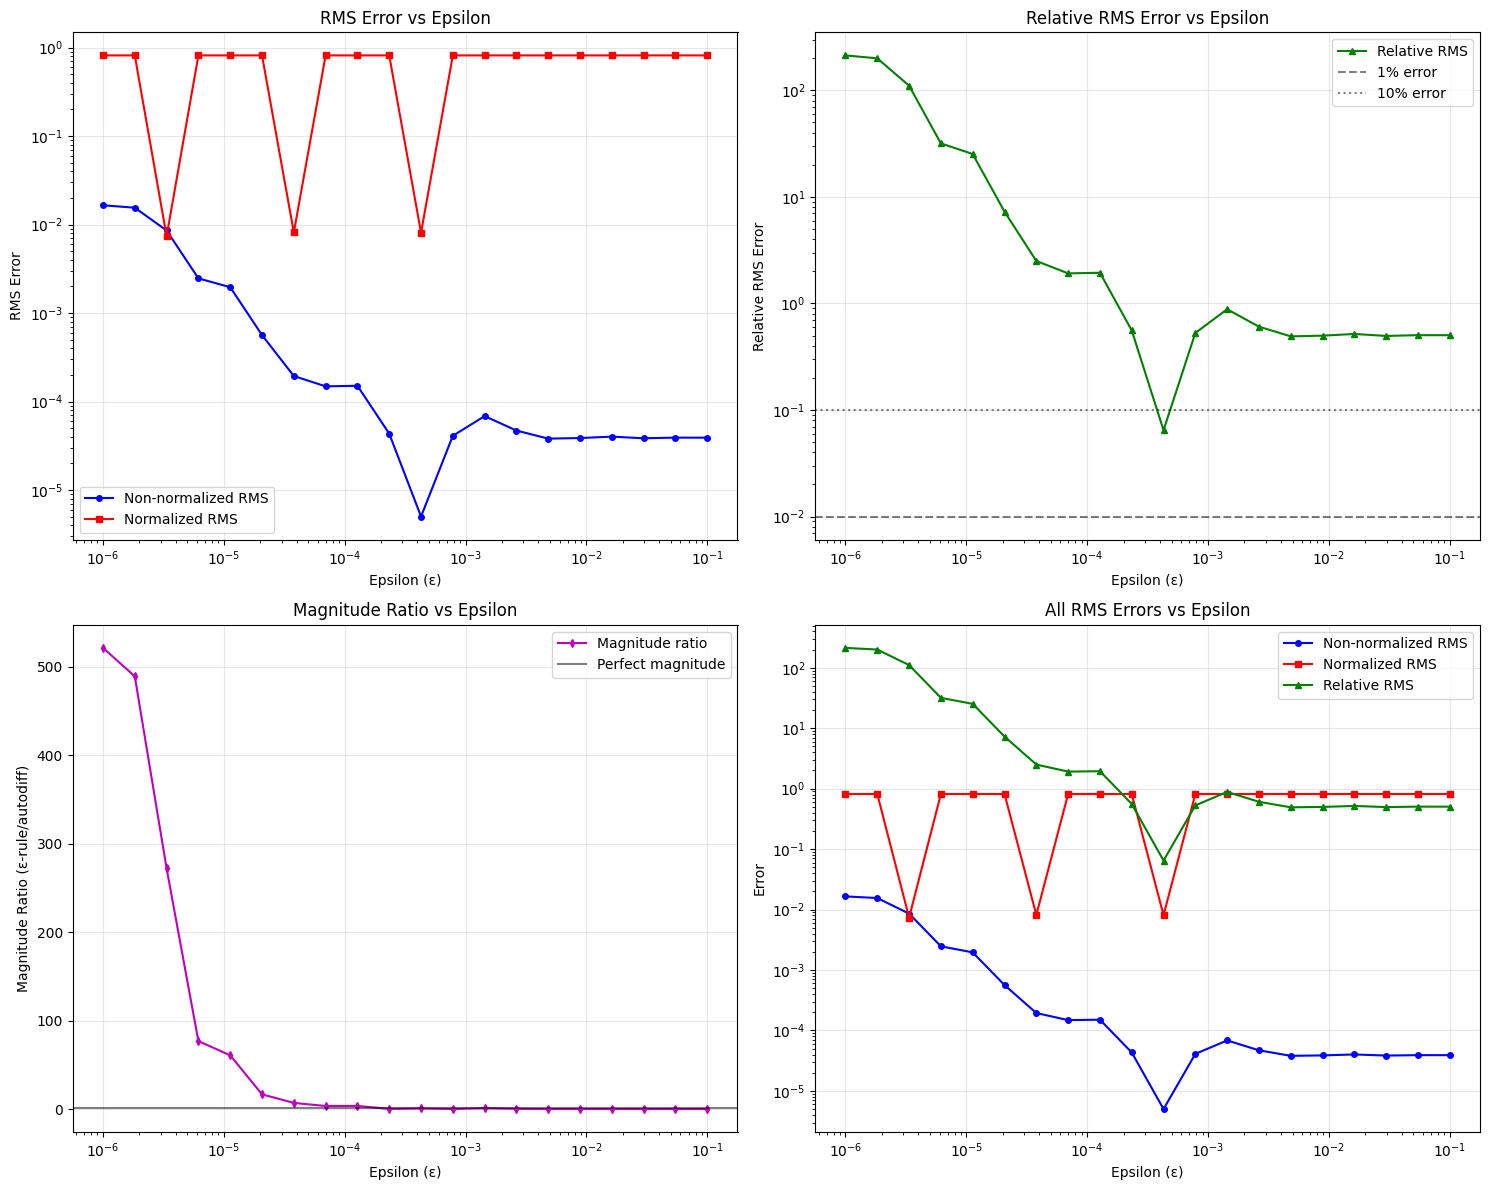

\nOptimal epsilon: 4.3e-04
Best relative RMS error: 0.064651
At optimal epsilon:
  Non-normalized RMS: 5.01e-06
  Normalized RMS:     0.008076
  Magnitude ratio:    0.8427


In [51]:
# Epsilon sweep analysis for ε-rule gradient
import matplotlib.pyplot as plt

print("=== EPSILON SWEEP ANALYSIS ===")

# Define epsilon values to sweep (logarithmically spaced)
epsilon_values = jnp.logspace(-6, -1, 20)  # from 1e-6 to 1e-1
print(f"Sweeping {len(epsilon_values)} epsilon values from {epsilon_values[0]:.1e} to {epsilon_values[-1]:.1e}")

# Storage for results
rms_non_normalized_list = []
rms_normalized_list = []
relative_rms_list = []
magnitude_ratios = []

# Helper functions
def normalize_vector(v):
    norm = jnp.linalg.norm(v)
    return v / norm if norm > 1e-12 else v

def compute_rms_error(v1, v2):
    return jnp.sqrt(jnp.mean((v1 - v2)**2))

# Compute reference values
norm_auto = jnp.linalg.norm(grad_auto)
grad_auto_normalized = normalize_vector(grad_auto)

print("Computing gradients for each epsilon...")
for i, eps in enumerate(epsilon_values):
    if i % 5 == 0:  # Progress indicator
        print(f"  {i+1}/{len(epsilon_values)}: ε = {eps:.1e}")
    
    # Compute ε-rule gradient for this epsilon
    def w_dynamics_sweep(w, t, p):
        return dynamics(w, t, p) + eps * running_cost_grad_corrected(w, t)
    
    w_states_sweep = odeint(w_dynamics_sweep, init_x, ts, p_test)
    v_states_sweep = w_states_sweep - xs
    
    ints_eps_sweep = []
    for v, x, t in zip(v_states_sweep, xs, ts):
        Jp = jac_params(x, t, p_test)
        ints_eps_sweep.append((v[:,None].T @ Jp)[0])
    ints_eps_sweep = jnp.stack(ints_eps_sweep)
    grad_eps_sweep = -(1/eps) * jnp.trapezoid(ints_eps_sweep, ts, axis=0)
    
    # Normalize this gradient
    grad_eps_sweep_normalized = normalize_vector(grad_eps_sweep)
    
    # Compute RMS errors
    rms_non_norm = compute_rms_error(grad_eps_sweep, grad_auto)
    rms_norm = compute_rms_error(grad_eps_sweep_normalized, grad_auto_normalized)
    relative_rms = rms_non_norm / norm_auto
    magnitude_ratio = jnp.linalg.norm(grad_eps_sweep) / norm_auto
    
    # Store results
    rms_non_normalized_list.append(float(rms_non_norm))
    rms_normalized_list.append(float(rms_norm))
    relative_rms_list.append(float(relative_rms))
    magnitude_ratios.append(float(magnitude_ratio))

print("Creating plots...")

# Create multiple individual plots
plt.figure(figsize=(15, 12))

# Plot 1: RMS errors vs epsilon
plt.subplot(2, 2, 1)
plt.loglog(epsilon_values, rms_non_normalized_list, 'b-o', label='Non-normalized RMS', markersize=4)
plt.loglog(epsilon_values, rms_normalized_list, 'r-s', label='Normalized RMS', markersize=4)
plt.xlabel('Epsilon (ε)')
plt.ylabel('RMS Error')
plt.title('RMS Error vs Epsilon')
plt.grid(True, alpha=0.3)
plt.legend()

# Plot 2: Relative RMS error vs epsilon
plt.subplot(2, 2, 2)
plt.loglog(epsilon_values, relative_rms_list, 'g-^', label='Relative RMS', markersize=4)
plt.axhline(y=0.01, color='k', linestyle='--', alpha=0.5, label='1% error')
plt.axhline(y=0.1, color='k', linestyle=':', alpha=0.5, label='10% error')
plt.xlabel('Epsilon (ε)')
plt.ylabel('Relative RMS Error')
plt.title('Relative RMS Error vs Epsilon')
plt.grid(True, alpha=0.3)
plt.legend()

# Plot 3: Magnitude ratio vs epsilon
plt.subplot(2, 2, 3)
plt.semilogx(epsilon_values, magnitude_ratios, 'm-d', label='Magnitude ratio', markersize=4)
plt.axhline(y=1.0, color='k', linestyle='-', alpha=0.5, label='Perfect magnitude')
plt.xlabel('Epsilon (ε)')
plt.ylabel('Magnitude Ratio (ε-rule/autodiff)')
plt.title('Magnitude Ratio vs Epsilon')
plt.grid(True, alpha=0.3)
plt.legend()

# Plot 4: Summary - all RMS errors on same plot
plt.subplot(2, 2, 4)
plt.loglog(epsilon_values, rms_non_normalized_list, 'b-o', label='Non-normalized RMS', markersize=4)
plt.loglog(epsilon_values, rms_normalized_list, 'r-s', label='Normalized RMS', markersize=4)
plt.loglog(epsilon_values, relative_rms_list, 'g-^', label='Relative RMS', markersize=4)
plt.xlabel('Epsilon (ε)')
plt.ylabel('Error')
plt.title('All RMS Errors vs Epsilon')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# Find optimal epsilon
min_relative_idx = jnp.argmin(jnp.array(relative_rms_list))
optimal_eps = epsilon_values[min_relative_idx]
optimal_relative_rms = relative_rms_list[min_relative_idx]

print(f"\\nOptimal epsilon: {optimal_eps:.1e}")
print(f"Best relative RMS error: {optimal_relative_rms:.6f}")
print(f"At optimal epsilon:")
print(f"  Non-normalized RMS: {rms_non_normalized_list[min_relative_idx]:.2e}")
print(f"  Normalized RMS:     {rms_normalized_list[min_relative_idx]:.6f}")
print(f"  Magnitude ratio:    {magnitude_ratios[min_relative_idx]:.4f}")
